# Model Card

**Course:** IS 6850-004 
**Assignment:** Model Card  
**Student:** Hanrui Zhang

This notebook documents the final machine learning model developed for the lending decision project using the Home Credit dataset.

The purpose of this model card is to summarize the design, performance, threshold decision process, explainability, fairness considerations, and limitations of the model. The goal is to communicate model results in a format understandable to business stakeholders evaluating whether the model should be deployed in a lending decision system.

## Setup

This section loads the required libraries and prepares the environment for the analysis.  
The notebook will train a model, evaluate performance, determine an appropriate decision threshold, analyze explainability using SHAP values, and evaluate fairness across demographic groups.

In [10]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, precision_score, recall_score

from lightgbm import LGBMClassifier

import shap

## Data Loading

The dataset used in this analysis comes from the Home Credit Default Risk dataset.

Each row represents a loan application and includes financial, demographic, and credit history information about the applicant.

The target variable **TARGET** indicates whether the borrower experienced repayment difficulty.

In [11]:
df = pd.read_csv("application_train.csv")

print(df.shape)

df.head()

(307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## Data Preparation

The target variable for the model is **TARGET**, where:

- 1 indicates a borrower who experienced repayment difficulty (default risk)
- 0 indicates a borrower who successfully repaid the loan

For simplicity, only numeric features are used for modeling in this implementation.

In [13]:
y = df["TARGET"]

X = df.drop(columns=["TARGET"])

# keep numeric variables
X = X.select_dtypes(include=["number"])

## Train-Test Split

The dataset is split into training and validation sets.

The training set is used to train the machine learning model, while the validation set is used to evaluate model performance and perform threshold analysis.

In [14]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_valid.shape)

(246008, 105) (61503, 105)


## Model Training

A LightGBM classifier is used to predict the probability that a borrower will default.

LightGBM is well suited for structured tabular datasets and can capture nonlinear relationships between features and the target variable.

In [16]:
model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 19876, number of negative: 226132
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015258 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11484
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 100
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080794 -> initscore=-2.431606
[LightGBM] [Info] Start training from score -2.431606


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## Predicted Probabilities

The model produces a probability estimate representing the likelihood that a borrower will default.

These probabilities are used to evaluate model performance and determine the optimal threshold for lending decisions.

In [17]:
y_prob = model.predict_proba(X_valid)[:,1]

y_prob[:10]

array([0.15367802, 0.04354568, 0.13562629, 0.01994417, 0.04475772,
       0.19617402, 0.0399805 , 0.17087639, 0.09113592, 0.03397934])

## Performance Metrics

Model performance is evaluated using the Area Under the ROC Curve (AUC).

AUC measures the model's ability to distinguish between borrowers who will default and those who will not.

In [18]:
auc = roc_auc_score(y_valid, y_prob)

print("AUC:", round(auc,4))

AUC: 0.7542


## Decision Threshold Analysis

In lending applications, a decision threshold determines whether an applicant is approved or denied.

A lower threshold results in fewer approvals but reduces default risk.  
A higher threshold increases approval rates but may increase financial losses from defaults.

To determine an appropriate threshold, expected profit is evaluated under simplified business assumptions.

In [20]:
profit_if_repaid = 1200
loan_amount = 10000
recovery_rate = 0.25

loss_if_default = loan_amount * (1 - recovery_rate)

In [21]:
thresholds = np.arange(0.1,0.9,0.05)

results = []

for t in thresholds:

    approved = y_prob < t

    profit = np.where(
        (approved) & (y_valid==0),
        profit_if_repaid,
        np.where((approved)&(y_valid==1), -loss_if_default,0)
    ).sum()

    approval_rate = approved.mean()

    results.append((t,profit,approval_rate))

threshold_df = pd.DataFrame(results,columns=["threshold","profit","approval_rate"])

threshold_df

,threshold,profit,approval_rate
0,0.10,37520700.0,0.746386
1,0.15,38240400.0,0.863291
2,0.20,36991500.0,0.921223
3,0.25,35689200.0,0.954149
4,0.30,34117800.0,0.973644
5,0.35,32997000.0,0.985334
6,0.40,32213700.0,0.992049
7,0.45,31599900.0,0.995756
8,0.50,31200300.0,0.997886
9,0.55,30927000.0,0.999252


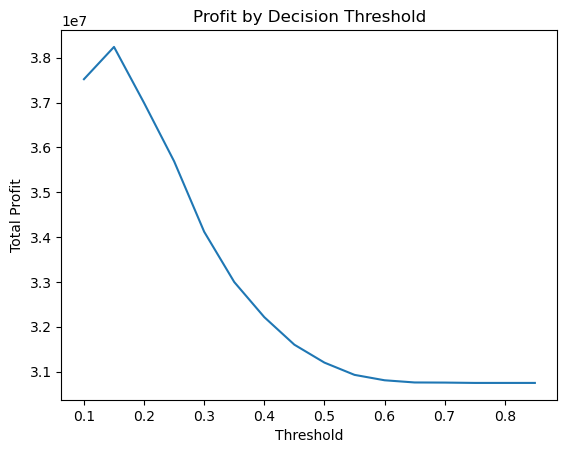

In [22]:
plt.plot(threshold_df["threshold"],threshold_df["profit"])
plt.xlabel("Threshold")
plt.ylabel("Total Profit")
plt.title("Profit by Decision Threshold")
plt.show()

In [23]:
best_row = threshold_df.loc[threshold_df["profit"].idxmax()]

best_row

threshold        1.500000e-01
profit           3.824040e+07
approval_rate    8.632912e-01
Name: 1, dtype: float64

## Explainability (SHAP)

SHAP (Shapley Additive Explanations) is used to interpret the model's predictions.

SHAP values estimate the contribution of each feature to the model's prediction.

To reduce computational cost, SHAP values are calculated using a sample of 1,000 observations from the validation dataset.

In [24]:
X_shap = X_valid.sample(1000, random_state=42)

In [25]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_shap)

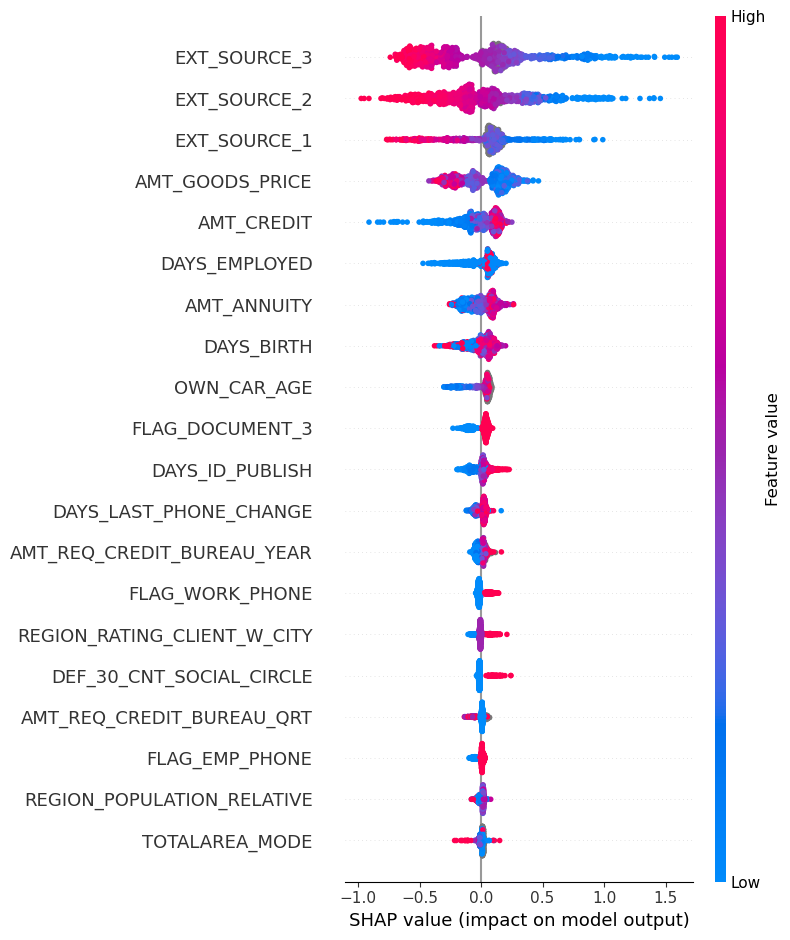

In [26]:
shap.summary_plot(shap_values, X_shap)

## Fairness Analysis

Fairness analysis evaluates whether the model produces significantly different outcomes across demographic groups.

This analysis compares approval rates across:

- Gender (CODE_GENDER)
- Education level (NAME_EDUCATION_TYPE)

In [27]:
fairness_df = df.loc[X_valid.index]

fairness_df["prob_default"] = y_prob

In [28]:
fairness_df["approved"] = fairness_df["prob_default"] < best_row["threshold"]

gender_approval = fairness_df.groupby("CODE_GENDER")["approved"].mean()

gender_approval

CODE_GENDER
F      0.879881
M      0.831078
XNA    1.000000
Name: approved, dtype: float64

In [29]:
education_approval = fairness_df.groupby("NAME_EDUCATION_TYPE")["approved"].mean()

education_approval

NAME_EDUCATION_TYPE
Academic degree                  0.852941
Higher education                 0.909478
Incomplete higher                0.837851
Lower secondary                  0.844049
Secondary / secondary special    0.849233
Name: approved, dtype: float64

## Limitations and Risks

Several limitations should be considered when interpreting the results of this model.

First, the model is trained using historical data, which may contain biases present in past lending decisions.

Second, economic conditions and borrower behavior may change over time, potentially reducing model performance in the future.

Third, differences in approval rates across demographic groups should be monitored carefully to ensure fair lending practices.

Finally, SHAP explanations provide insight into model behavior but do not guarantee fairness or regulatory compliance.

For these reasons, the model should be used as a decision support tool rather than a fully automated lending system.

## Adverse Action Mapping

Adverse action mapping translates technical model features into human-readable explanations for why an application may be denied.

In lending contexts, it is important that model decisions can be explained in understandable terms to both business stakeholders and applicants.

This section identifies the most important features influencing model predictions and maps them to plain-language explanations that could be communicated as potential denial reasons.

In [31]:
feature_importance = pd.DataFrame({
    "feature": X_valid.columns,
    "importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance.head(10)

,feature,importance
28,EXT_SOURCE_1,563
30,EXT_SOURCE_3,441
29,EXT_SOURCE_2,421
7,DAYS_BIRTH,379
3,AMT_CREDIT,334
4,AMT_ANNUITY,314
5,AMT_GOODS_PRICE,307
8,DAYS_EMPLOYED,255
10,DAYS_ID_PUBLISH,228
9,DAYS_REGISTRATION,177


### Mapping Technical Features to Human-Readable Reasons

The following table provides examples of how model features can be translated into understandable explanations for adverse lending decisions.

In [32]:
adverse_action_map = {
    
    "EXT_SOURCE_1": "Limited external credit history information",
    
    "EXT_SOURCE_2": "Limited external credit history information",
    
    "EXT_SOURCE_3": "Limited external credit history information",
    
    "AMT_CREDIT": "Requested credit amount is high relative to applicant risk profile",
    
    "AMT_ANNUITY": "Monthly loan payment appears high relative to income",
    
    "AMT_INCOME_TOTAL": "Reported income may be insufficient to support requested credit",
    
    "DAYS_EMPLOYED": "Employment history may be limited or unstable",
    
    "DAYS_BIRTH": "Applicant age profile is associated with elevated credit risk",
    
    "CNT_CHILDREN": "Household financial obligations may increase repayment risk",
    
    "DAYS_LAST_PHONE_CHANGE": "Recent changes in contact information may indicate instability"
}

adverse_action_map

{'EXT_SOURCE_1': 'Limited external credit history information',
 'EXT_SOURCE_2': 'Limited external credit history information',
 'EXT_SOURCE_3': 'Limited external credit history information',
 'AMT_CREDIT': 'Requested credit amount is high relative to applicant risk profile',
 'AMT_ANNUITY': 'Monthly loan payment appears high relative to income',
 'AMT_INCOME_TOTAL': 'Reported income may be insufficient to support requested credit',
 'DAYS_EMPLOYED': 'Employment history may be limited or unstable',
 'DAYS_BIRTH': 'Applicant age profile is associated with elevated credit risk',
 'CNT_CHILDREN': 'Household financial obligations may increase repayment risk',
 'DAYS_LAST_PHONE_CHANGE': 'Recent changes in contact information may indicate instability'}

In [33]:
top_features = feature_importance.head(5)["feature"]

for feature in top_features:
    
    if feature in adverse_action_map:
        
        print(feature, ":", adverse_action_map[feature])

EXT_SOURCE_1 : Limited external credit history information
EXT_SOURCE_3 : Limited external credit history information
EXT_SOURCE_2 : Limited external credit history information
DAYS_BIRTH : Applicant age profile is associated with elevated credit risk
AMT_CREDIT : Requested credit amount is high relative to applicant risk profile


### Interpretation

The adverse action mapping step translates technical model features into explanations that can be understood by non-technical stakeholders.

For example, if the model identifies high risk due to variables related to credit history or repayment burden, those signals can be translated into explanations such as limited credit history, high payment obligations, or insufficient income relative to requested credit.

Providing these explanations improves transparency and helps ensure that model-based lending decisions remain interpretable and accountable.

In [37]:
!jupyter nbconvert --to html --no-input model_card.ipynb

[NbConvertApp] Converting notebook model_card.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 532477 bytes to model_card.html
